In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv('IPL.csv')
# Show first 5 rows
df.head()

C:\Users\sarth\AppData\Local\Temp\ipykernel_1568\4099492419.py:3: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [2]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 64 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         278205 non-null  int64  
 1   match_id           278205 non-null  int64  
 2   date               278205 non-null  object 
 3   match_type         278205 non-null  object 
 4   event_name         278205 non-null  object 
 5   innings            278205 non-null  int64  
 6   batting_team       278205 non-null  object 
 7   bowling_team       278205 non-null  object 
 8   over               278205 non-null  int64  
 9   ball               278205 non-null  int64  
 10  ball_no            278205 non-null  float64
 11  batter             278205 non-null  object 
 12  bat_pos            278205 non-null  int64  
 13  runs_batter        278205 non-null  int64  
 14  balls_faced        278205 non-null  int64  
 15  bowler             278205 non-null  object 
 16  va

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         264884
striker_out              0
Length: 64, dtype: int64

In [3]:
# Create a match-level dataframe
match_df = df.groupby('match_id').agg({
    'batting_team': 'first',
    'bowling_team': 'first',
    'toss_winner': 'first',
    'toss_decision': 'first',
    'venue': 'first',
    'city': 'first',
    'season': 'first',
    'match_won_by': 'first'
}).reset_index()

match_df.head()

,match_id,batting_team,bowling_team,toss_winner,toss_decision,venue,city,season,match_won_by
0,335982,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Kolkata Knight Riders
1,335983,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,2007/08,Chennai Super Kings
2,335984,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,2007/08,Delhi Daredevils
3,335985,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Mumbai,2007/08,Royal Challengers Bangalore
4,335986,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Eden Gardens,Kolkata,2007/08,Kolkata Knight Riders


In [4]:
# Remove rows where match_won_by is Unknown
match_df = match_df[match_df['match_won_by'] != 'Unknown'].reset_index(drop=True)

In [5]:
from sklearn.preprocessing import LabelEncoder

# Encoder for team names
le_team = LabelEncoder()
le_team.fit(pd.concat([match_df['batting_team'], match_df['bowling_team'], match_df['toss_winner']]))

# Transform teams
match_df['batting_team_enc'] = le_team.transform(match_df['batting_team'])
match_df['bowling_team_enc'] = le_team.transform(match_df['bowling_team'])
match_df['toss_winner_enc'] = le_team.transform(match_df['toss_winner'])

# Encoder for match winner (target)
le_winner = LabelEncoder()
match_df['match_winner_enc'] = le_winner.fit_transform(match_df['match_won_by'])

In [6]:
# Encode toss decision
match_df['toss_decision_enc'] = match_df['toss_decision'].map({'bat': 0, 'field': 1})

In [7]:
X = match_df[['batting_team_enc', 'bowling_team_enc', 'toss_winner_enc', 'toss_decision_enc']]
y = match_df['match_winner_enc']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

Accuracy: 0.4956521739130435


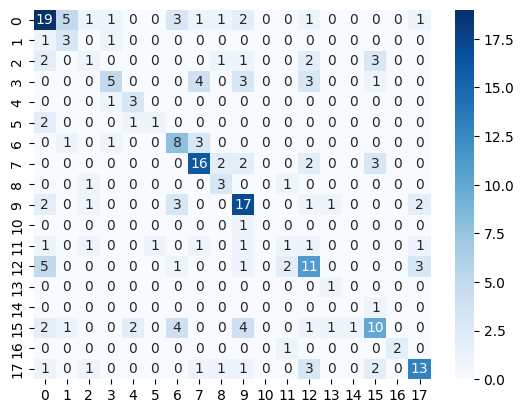

              precision    recall  f1-score   support

           0       0.54      0.54      0.54        35
           1       0.30      0.60      0.40         5
           2       0.17      0.10      0.12        10
           3       0.56      0.31      0.40        16
           4       0.50      0.75      0.60         4
           5       0.50      0.25      0.33         4
           6       0.42      0.62      0.50        13
           8       0.62      0.64      0.63        25
           9       0.38      0.60      0.46         5
          10       0.52      0.63      0.57        27
          11       0.00      0.00      0.00         1
          12       0.20      0.12      0.15         8
          13       0.44      0.48      0.46        23
          14       0.33      1.00      0.50         1
          15       0.00      0.00      0.00         1
          16       0.50      0.38      0.43        26
          17       1.00      0.67      0.80         3
          18       0.65    

C:\Users\sarth\OneDrive\Desktop\ML_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarth\OneDrive\Desktop\ML_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sarth\OneDrive\Desktop\ML_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

# Detailed report
print(classification_report(y_test, y_pred))

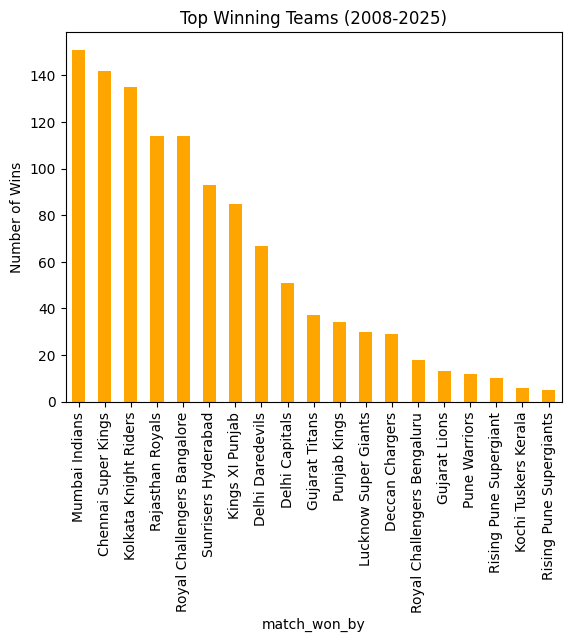

In [11]:
match_df['match_won_by'].value_counts().plot(kind='bar', color='orange')
plt.title('Top Winning Teams (2008-2025)')
plt.ylabel('Number of Wins')
plt.savefig('top_winning_teams.png', dpi=300, bbox_inches='tight')  # dpi=300 for high quality
plt.show()

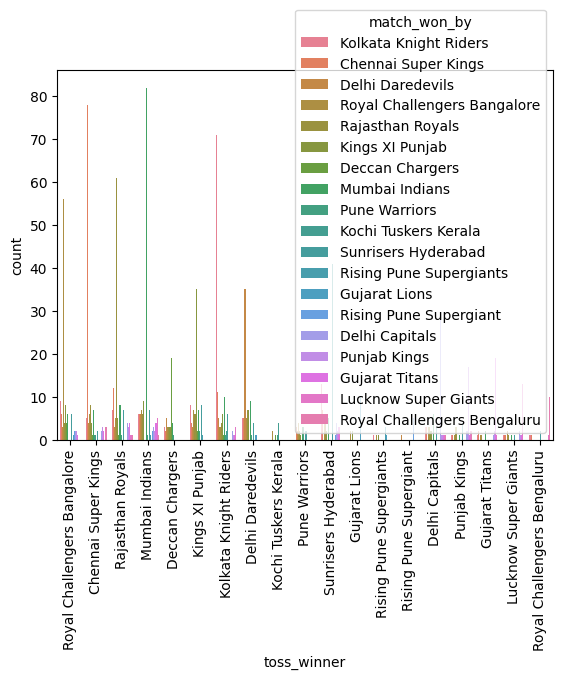

In [12]:
#Toss winner vs Match winner"
sns.countplot(x='toss_winner', hue='match_won_by', data=match_df)
plt.xticks(rotation=90)
plt.savefig('toss_winner_vs_match_winner.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
import joblib
joblib.dump(rf_model, 'ipl_match_winner_model.pkl')

['ipl_match_winner_model.pkl']

In [14]:
# Example match
batting_team = 'Mumbai Indians'
bowling_team = 'Chennai Super Kings'
toss_winner = 'Mumbai Indians'
toss_decision = 'field'  # or 'bat'

# Encode using the same LabelEncoder used for training
batting_team_enc = le_team.transform([batting_team])[0]
bowling_team_enc = le_team.transform([bowling_team])[0]
toss_winner_enc = le_team.transform([toss_winner])[0]
toss_decision_enc = 1 if toss_decision == 'field' else 0

In [15]:
# Now predict
prediction = model.predict([[batting_team_enc, bowling_team_enc, toss_winner_enc, toss_decision_enc]])

# Convert prediction back to team name
predicted_winner = le_winner.inverse_transform(prediction)[0]
print("Predicted Winner:", predicted_winner)

NameError: name 'model' is not defined